In [1]:
from lib import epl as EPL 
from lib import OSN
from lib import readout
from lib import plots
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import time
import numpy as np
import pickle 

# #Load Data
# rf = open('./data/multiOdorTest.pi', 'r');
# trainingOdors = np.array(pickle.load(rf));
# testOdors = np.array(pickle.load(rf));
# rf.close();

trainingOdors, testOdors = np.load('multiOdorTest.npy', fix_imports=True, allow_pickle=True); 

In [2]:
nOdors = len(trainingOdors); 
nGammaPerOdor = 5
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = EPL.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
t1 = time.time(); 
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    
    #we added this loop
for i in range(0, len(trainingOdors)):
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i%10==0 and i!=0):
        print(str(i) + " odors tested"); 
t2 = time.time(); 
print("Simulation Duration = " + str(t2-t1) + "s")

#Readout
from my_lib import my_readout

sMatrix = my_readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  

#Plots
# plots.plotFigure4a(epl.gammaCode, nMCs = nMCs, nGamma = nGammaPerOdor)
# plots.plotFigure4b(sMatrix); 
# plots.plotFigure4d(epl.gammaCode, sMatrix); 

Number of odors to train = 10
Number of odors to test = 100
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
Training odor 7
Training odor 8
Training odor 9
Training odor 10
10 odors tested
20 odors tested
30 odors tested
40 odors tested
50 odors tested
60 odors tested
70 odors tested
80 odors tested
90 odors tested
Simulation Duration = 963.6460230350494s


In [3]:
len(sMatrix), len(sMatrix[0])

(500, 10)

# plotFigure3b = gammaLearning (good name?)
"Odourant-evoked MC activity patterns are attracted to learned representations"

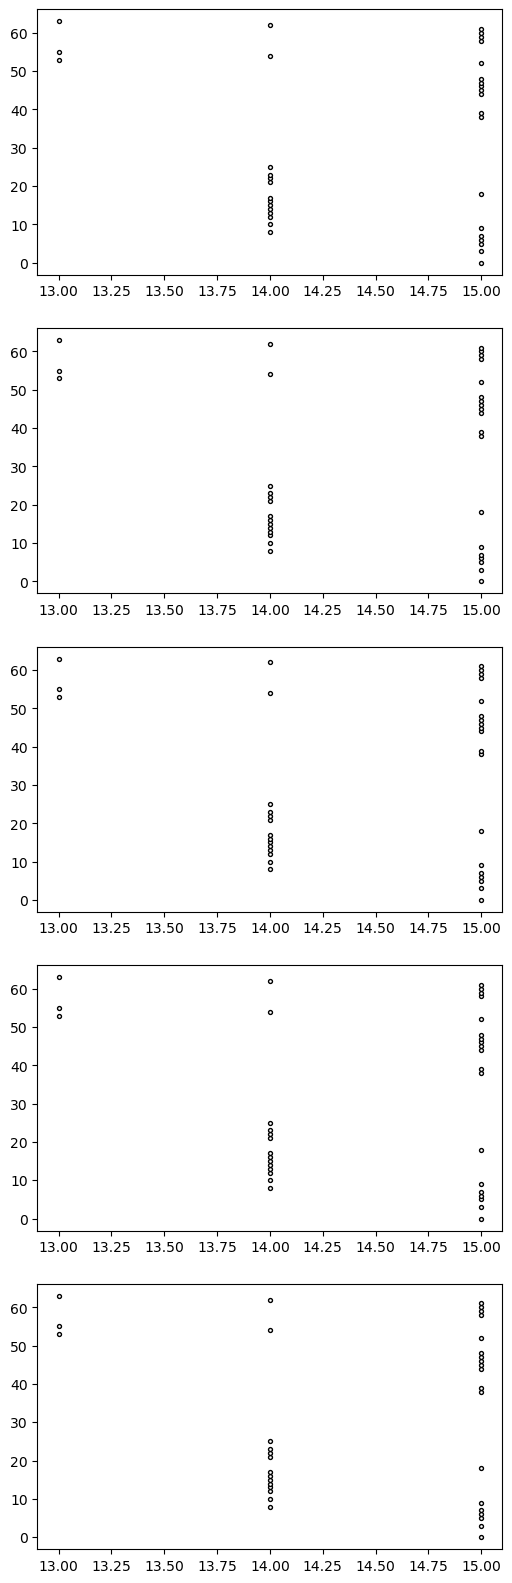

In [4]:
pre.my_plotFigure3b(epl.gammaCode, 1, nMCs, nGamma = nGammaPerOdor)


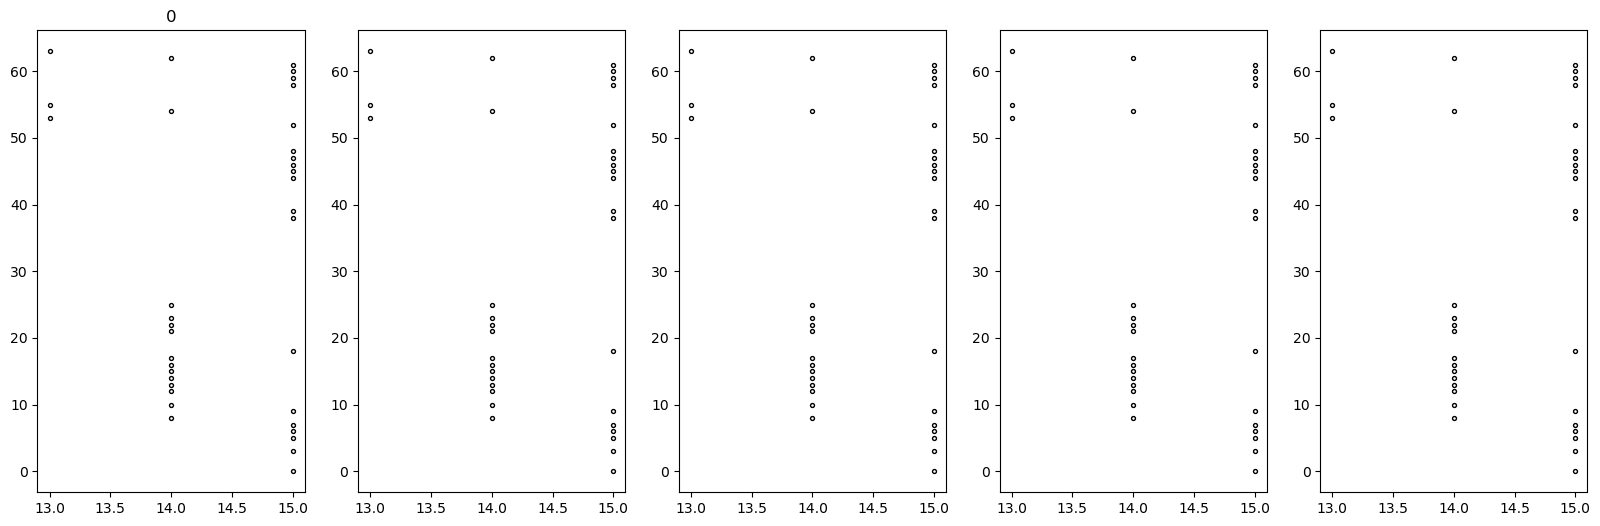

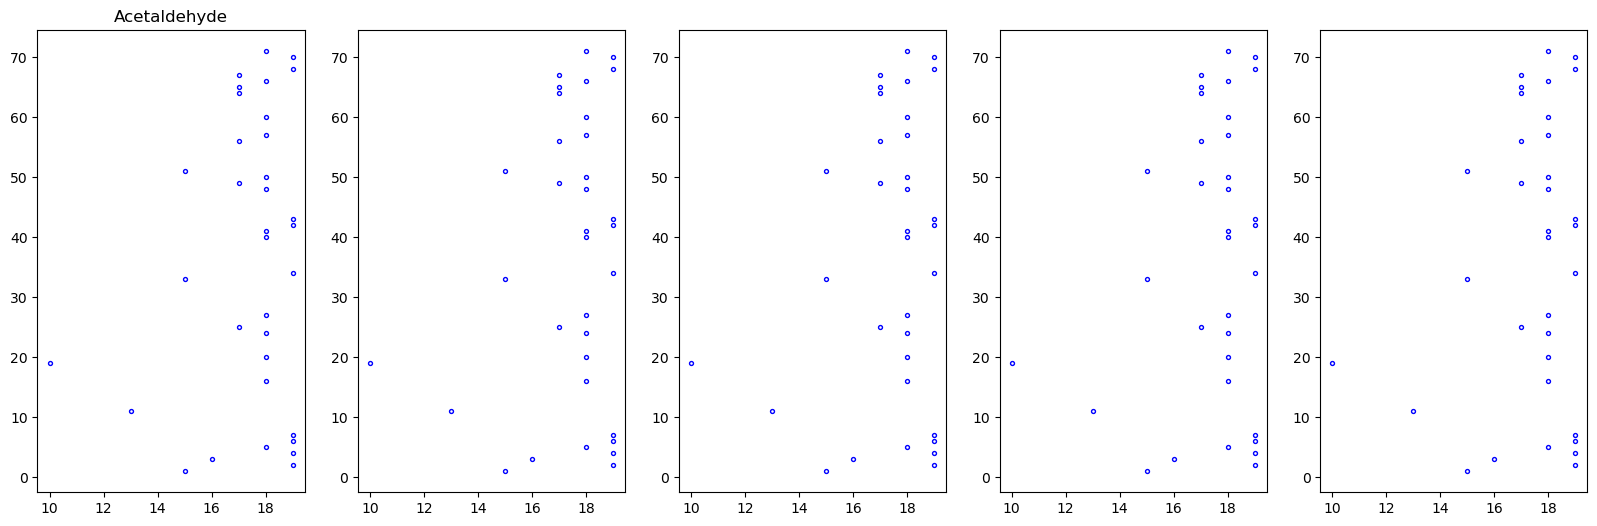

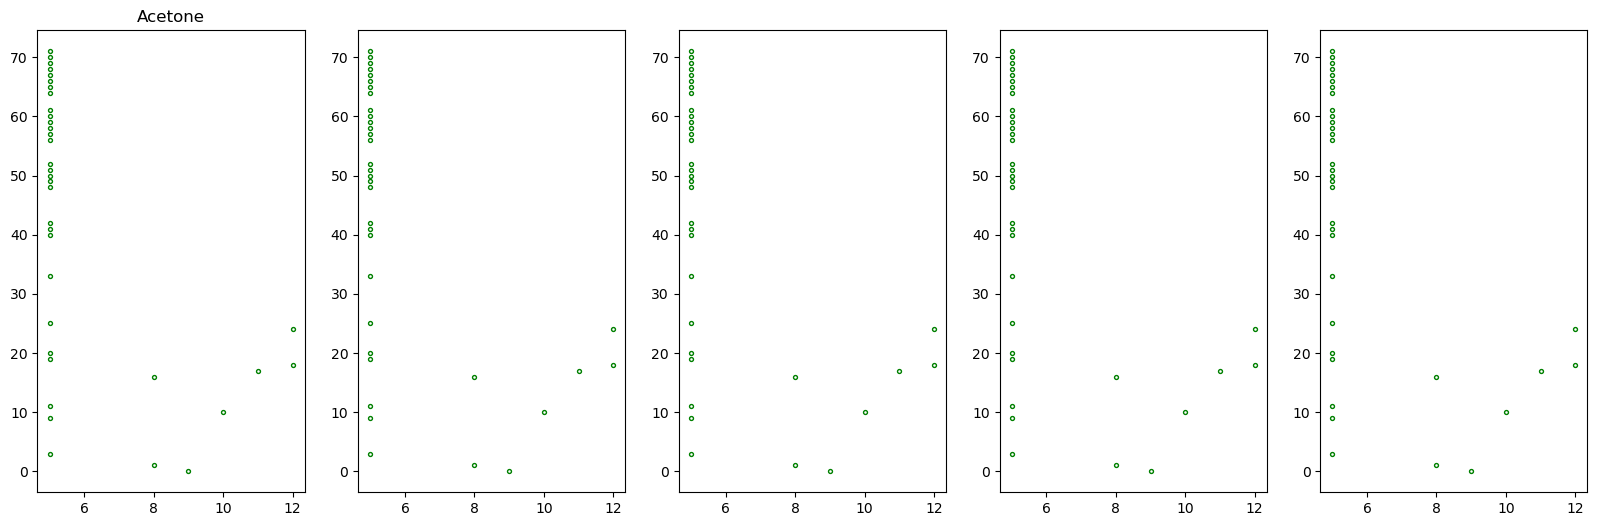

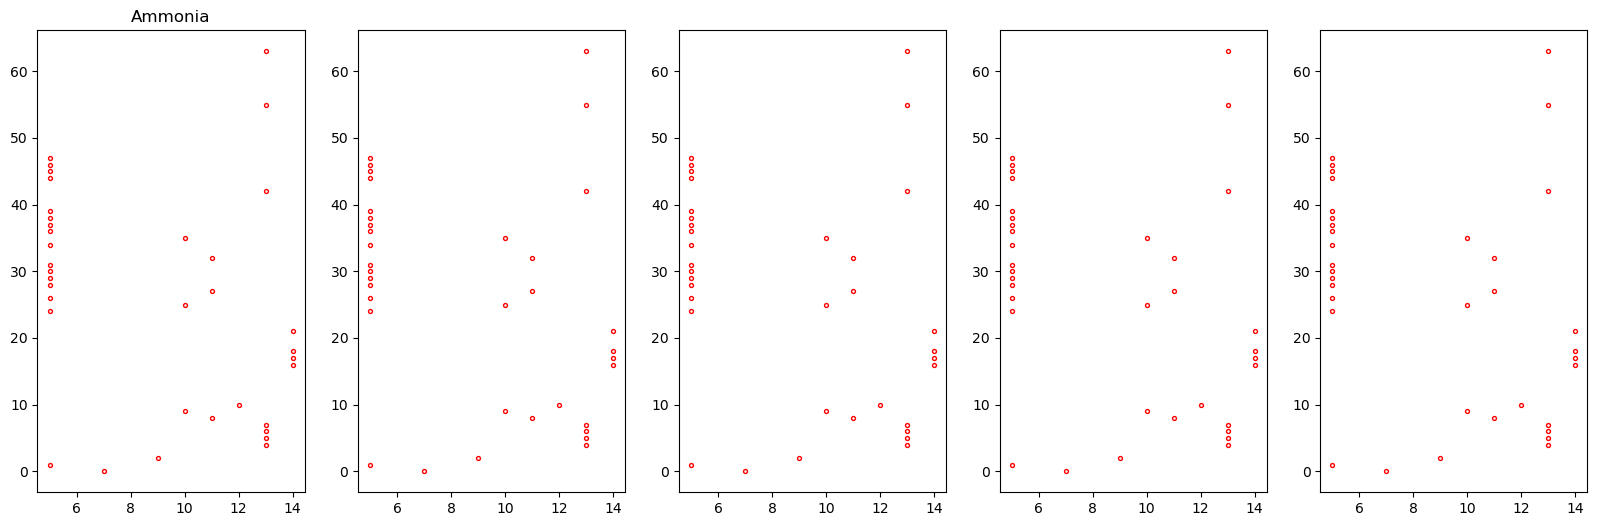

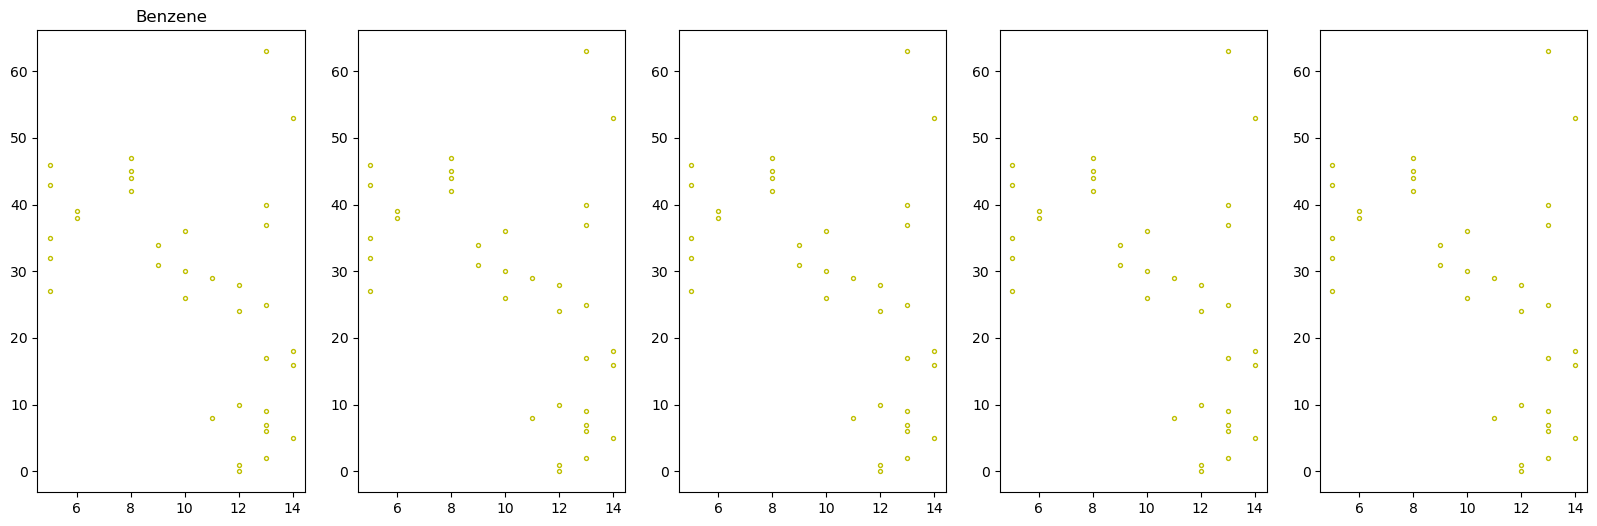

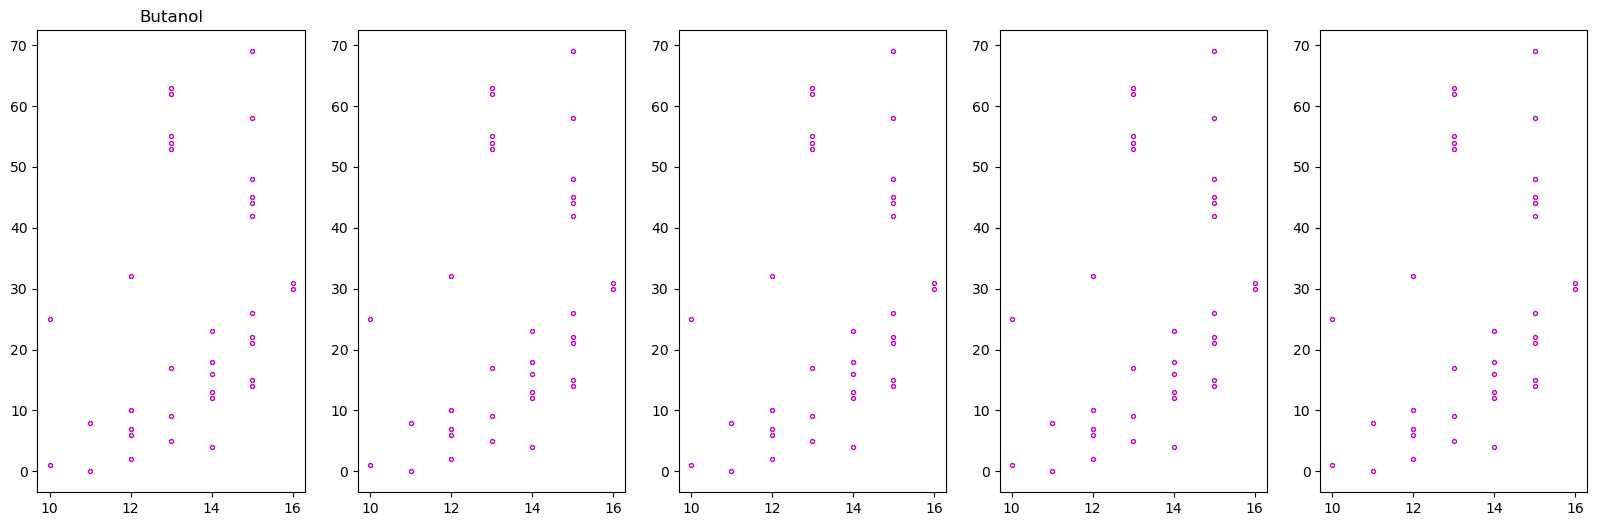

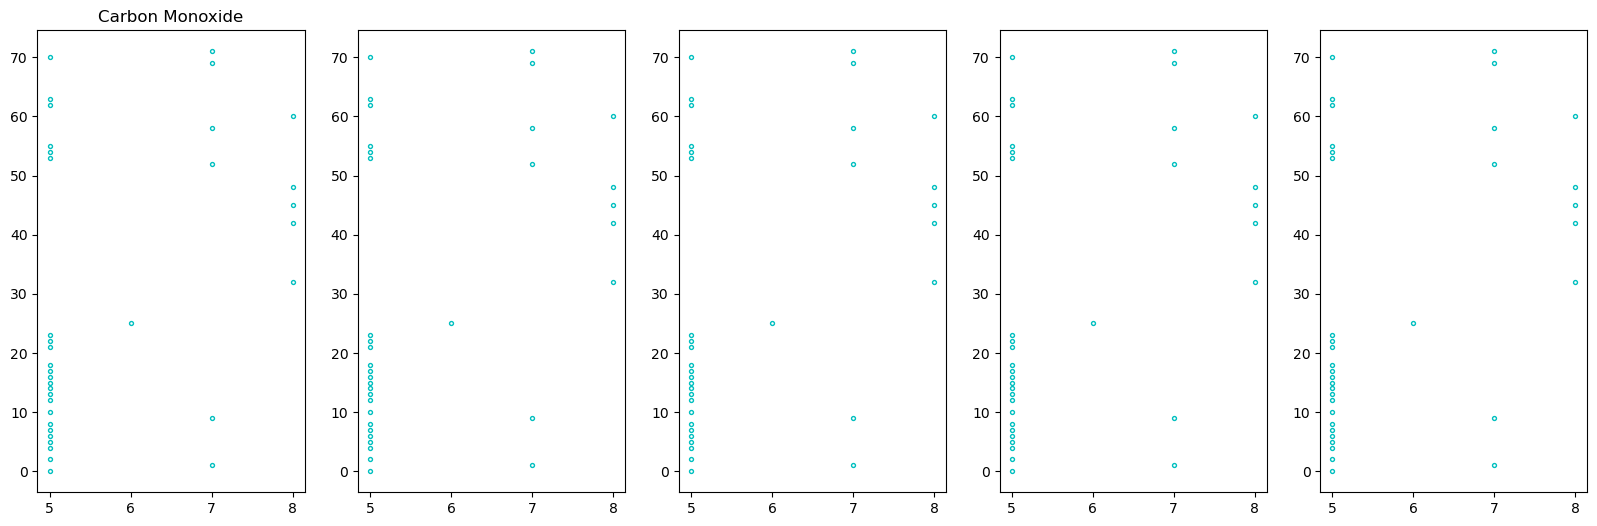

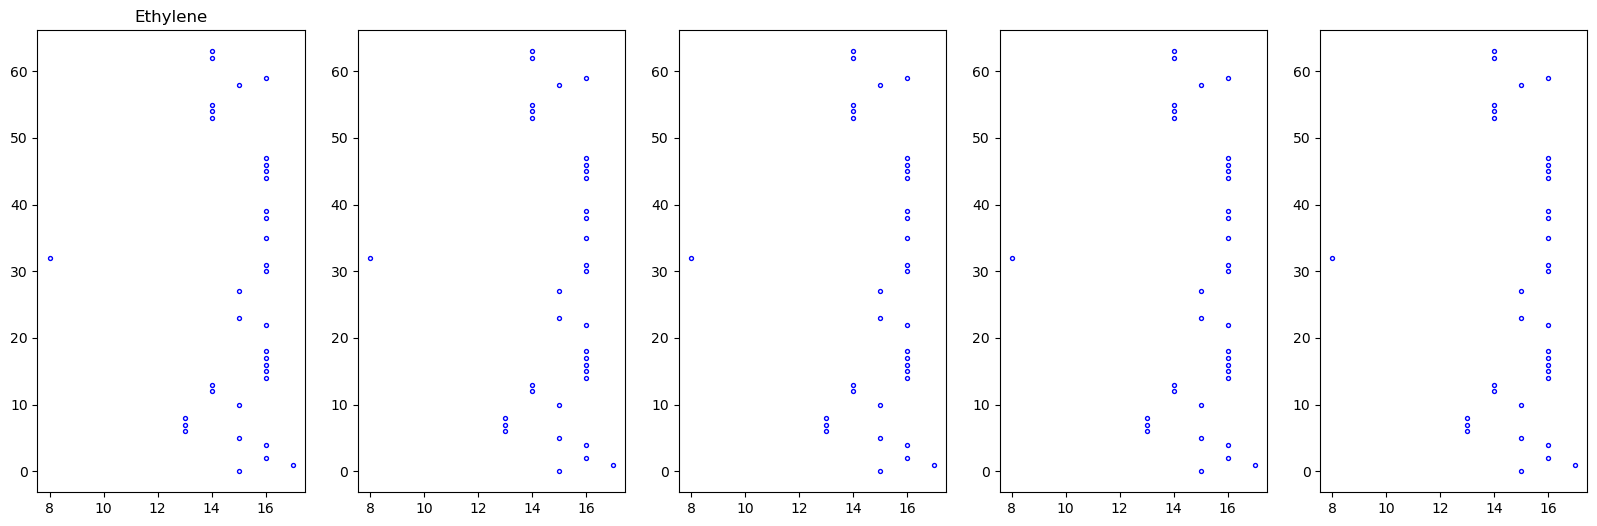

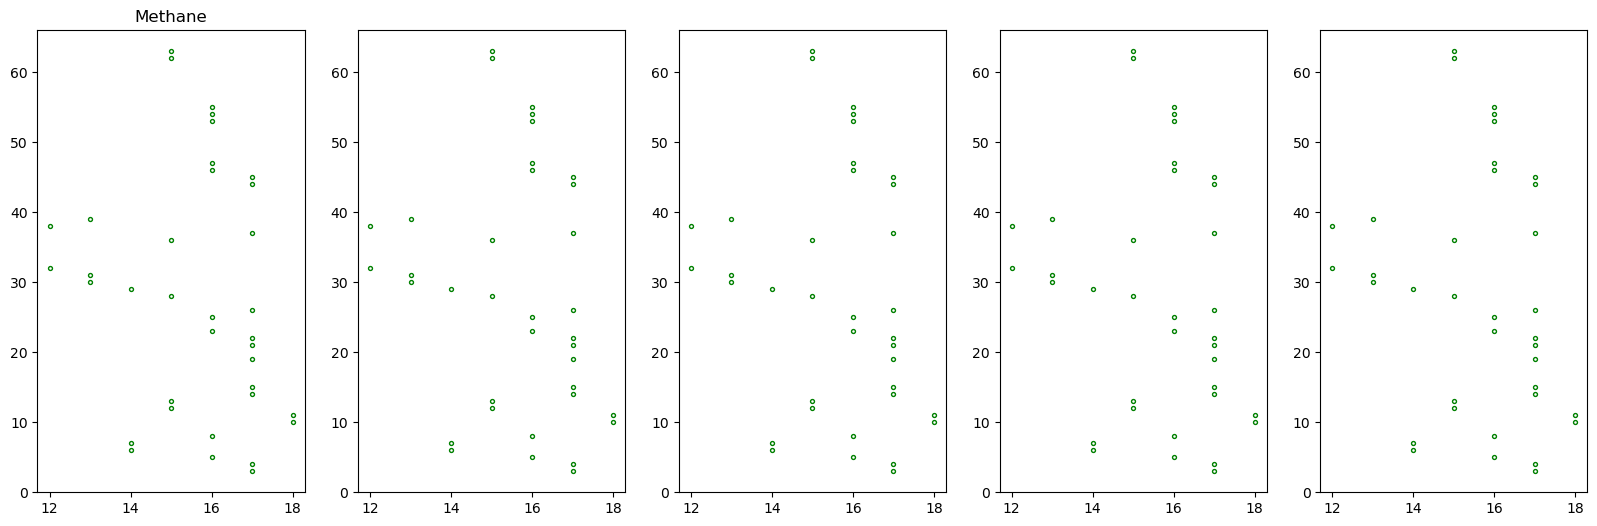

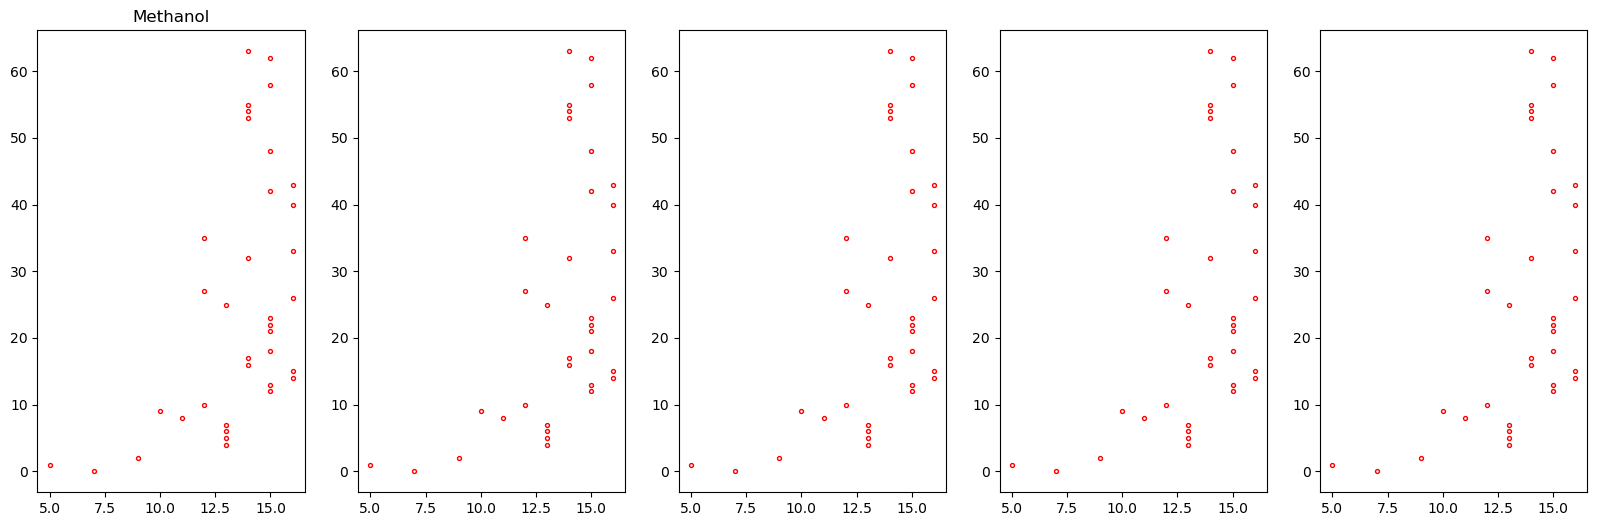

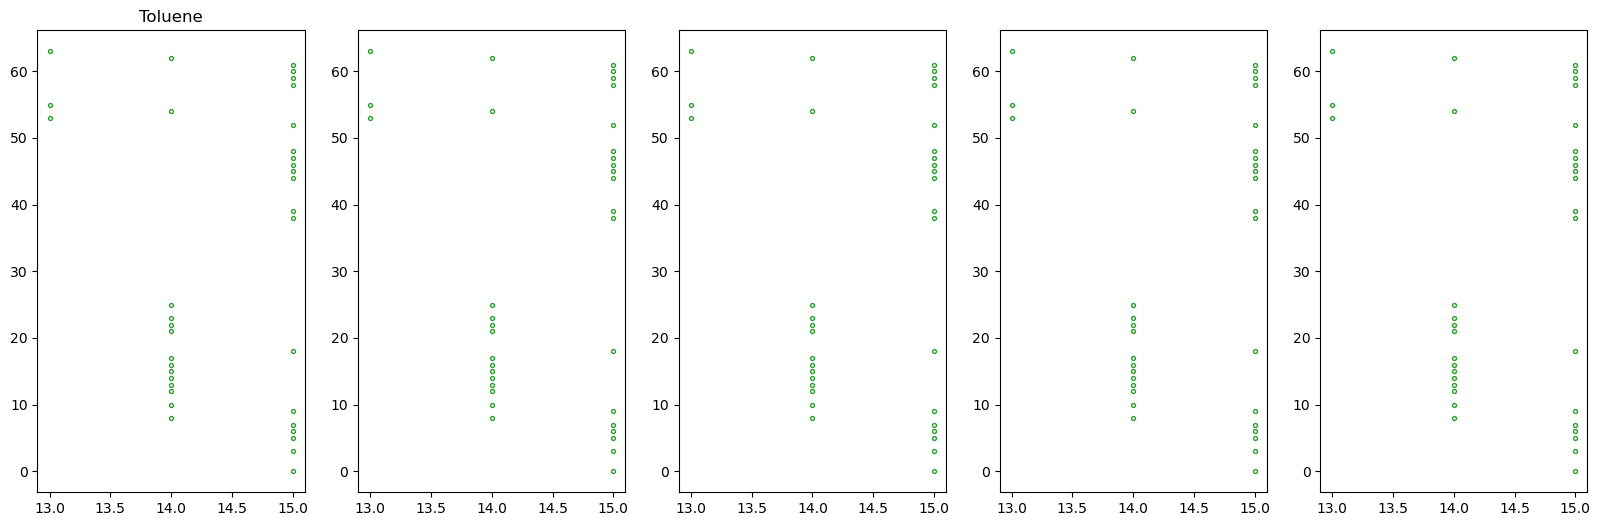

In [5]:
def gammaLearning(gammaCode, epoch, nMCs, plotTitles, nGamma = 5, figsize = (6,20)): 
    color = ['k','b', 'g', 'r', 'y', 'm', 'c','b', 'g', 'r', 'C2', 'C3']
    plt.figure(epoch,figsize)
    alignment = '15' #'15' means 1 row 5 columns and pairs with figsize (20,6)
    #print(str(correlating_digit) + color[epoch-1]) #plt.title(epoch)
    for i in range(0, nGamma):
        s = int(alignment+str(i+1))
        plt.subplot(s);
        if(i==0):
            if epoch == 1:
                plt.title(str(0))
            else:
                plt.title(str(plotTitles[epoch-2]))
        for j in range(0, nMCs):
            #Learned Toluene
            gammaID = epoch*nGamma + i; 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                #plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor='k')
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=color[epoch-1])

plotTitles = ['Acetaldehyde', 'Acetone', 'Ammonia', 'Benzene', 'Butanol', 'Carbon Monoxide', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];
for epoch in range(1,12):
    gammaLearning(epl.gammaCode, epoch, epl.nMCs, plotTitles,nGamma=5, figsize = (20,6))


# my_plotFigure4a experimentation

In [6]:
(len(epl.gammaCode), len(epl.gammaCode[1]))

(600, 72)

In [7]:
sum(epl.gammaCode, []) #way of flattening list

[13.0,
 15.0,
 11.0,
 0,
 7.0,
 7.0,
 7.0,
 7.0,
 9.0,
 10.0,
 8.0,
 0,
 5.0,
 5.0,
 4.0,
 4.0,
 6.0,
 6.0,
 5.0,
 0,
 0,
 5.0,
 5.0,
 5.0,
 0,
 7.0,
 4.0,
 8.0,
 0,
 0,
 0,
 0,
 6.0,
 4.0,
 0,
 8.0,
 0,
 0,
 0,
 0,
 4.0,
 0,
 5.0,
 4.0,
 0,
 0,
 0,
 0,
 5.0,
 0,
 0,
 0,
 0,
 6.0,
 6.0,
 6.0,
 0,
 0,
 5.0,
 0,
 0,
 0,
 5.0,
 6.0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 13.0,
 15.0,
 11.0,
 0,
 7.0,
 7.0,
 7.0,
 7.0,
 9.0,
 10.0,
 8.0,
 0,
 5.0,
 5.0,
 4.0,
 4.0,
 6.0,
 6.0,
 5.0,
 0,
 0,
 5.0,
 5.0,
 5.0,
 0,
 7.0,
 4.0,
 8.0,
 0,
 0,
 0,
 0,
 6.0,
 4.0,
 0,
 8.0,
 0,
 0,
 0,
 0,
 4.0,
 0,
 5.0,
 4.0,
 0,
 0,
 0,
 0,
 5.0,
 0,
 0,
 0,
 0,
 6.0,
 6.0,
 6.0,
 0,
 0,
 5.0,
 0,
 0,
 0,
 5.0,
 6.0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 13.0,
 15.0,
 11.0,
 0,
 7.0,
 7.0,
 7.0,
 7.0,
 9.0,
 10.0,
 8.0,
 0,
 5.0,
 5.0,
 4.0,
 4.0,
 6.0,
 6.0,
 5.0,
 0,
 0,
 5.0,
 5.0,
 5.0,
 0,
 7.0,
 4.0,
 8.0,
 0,
 0,
 0,
 0,
 6.0,
 4.0,
 0,
 8.0,
 0,
 0,
 0,
 0,
 4.0,
 0,
 5.0,
 4.0,
 0,
 0,
 0,
 0,
 5.0,
 0,
 0,
 0,


In [8]:
indices = [i for i, x in enumerate(sum(epl.gammaCode, [])) if x == 0]
indices[:] = [x / nMCs for x in indices]

In [9]:
def my_plotFigure4a(gammaCode, nMCs = 72, nGamma = 5): 
    plt.figure(1, figsize=(6, 20))
    plt.title("My Figure 4a")
    
    for i in range(0, nGamma):
        
        #formatting
        s = int('42'+str(i+1)) #4 columns and 2 rows
        plt.subplot(s);
        plt.title("My Figure 4a " + str(i+1))
        
        #
        for j in range(0, nMCs):
            
            #Learned Toluene they have: 9 
            # i want: 54
            #gammaID = 0*nGamma + 9; 
            gammaID = 50+ nGamma*1 -1 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=(0, 0, 1, 1))
            
            #Learned Acetone 50+9 59
            #i want: 79
            #gammaID = 5*5*2 + 9;       #Acetone is odor # 6
            gammaID = 50 + 6*nGamma - 1
            if gammaCode[gammaID][j] != 0: 
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor=(1, 0, 0, 0.25))
            
            #Occluded Toluene 100, 101, 102, 103, 104
            gammaID = 100 + i; 
            if gammaCode[gammaID][j] != 0:
                spikeTime = 20 - gammaCode[gammaID][j]; 
                plt.scatter(spikeTime, j, s= 2, marker = 'o', color = 'k'); 
           
        
            plt.ylim([-2,nMCs])
            offset = 40*i; 
            plt.xticks([0, 4, 8, 12, 16, 20], [offset+0, offset+4, offset+8, offset+12, offset+16, offset+20]); 
            plt.yticks(range(nMCs/4, nMCs+1, nMCs/4)); 
    plt.xlabel('Timesteps');
    plt.ylabel('MC Index');  
    

    plt.show(); 

TypeError: 'float' object cannot be interpreted as an integer

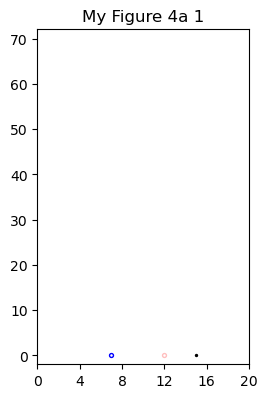

In [10]:
my_plotFigure4a(epl.gammaCode, nMCs = nMCs, nGamma = nGammaPerOdor)

In [1]:
plots.plotFigure4a(epl.gammaCode, nMCs = nMCs, nGamma = nGammaPerOdor)


NameError: name 'plots' is not defined

# Experimentation with rasterSimilarityPlot (my_plotFigure4d)

In [ ]:
plotTitles = ['Acetaldehyde', 'Acetone', 'Ammonia', 'Benzene', 'Butanol', 'Carbon Monoxide', 'Ethylene', 'Methane', 'Methanol', 'Toluene'];
pre.rasterSimilarityPlot(epl.gammaCode, sMatrix, plotTitles, nMCs = nMCs, nOdors = nOdors, nGamma = nGammaPerOdor)

# parsing of epl.gammaCode

In [ ]:
ignore = epl.gammaCode[:50]
templates = epl.gammaCode[50:100]
testing = epl.gammaCode[100:]

Reformat in 3D arrays

In [ ]:
templatess = templates[4::5]

In [ ]:
testingg = []
for x in range(0, len(testing), 5):
    testingg.append(testing[x+4])

# my_Figure 5i

add ypoints to readout code

In [ ]:
ypoints = [1]
templateID = 0
"""
10 is the number of occluded version of any given odor in testing (along levels of occlusion)
"""
for i in range(0,10):
    #ypoints.append(readout.jaccardSimilarity(templatess[0][4], testingg[i][4]))
    ypoints.append(readout.computeSimilarity(templatess[templateID], testingg[templateID*10 + i]))

In [ ]:
xpoints = np.linspace(0,1,11)
ypoints = np.array(ypoints)


plt.plot(xpoints, ypoints, 's',ls = '--', c = 'g')
#plt.plot([0,xpoints[-1]], [.75, .75])
plt.xlabel('Proportion occluded')
plt.ylabel('similarity')
plt.title('Figure 5i')
plt.show()

## Now, I want to make a decision matrix

In [ ]:
# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)

In [ ]:
SImatrix = np.zeros((len(trainingOdors[0]), len(testOdors[0])), dtype =float)  
for i in range(0, len(trainingOdors[-1])):
    for j in range(0, len(testOdors[-1])):
        SImatrix[i][j] = (computeSimilarity(trainingOdors[-1][i], testOdors[-1][j]))


decisionMatrix = (SImatrix> 0.75)

truthMatrix = np.equal(digits.T, test_digits)
truthMatrix.shape
#digits which is a 2d array, use reshape to 
#operations broadcasting when comparing two arrays of different dimensions

#this is not decisionMatrix xor truthMatrix
#returns all the places where the decision is correct (trues are trues and falses re false)
#take a look at this logic
# Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
correct = ~(decisionMatrix ^ truthMatrix)

correctID = np.count_nonzero(correct)
per_correct = float(correctID)/SImatrix.size *100

correctness.append(per_correct)